# Vector Field - 3 Robot Algorithms

This is going to be the master file. It allows you to create any vector field of your choice, allows you to define your robot cluster, and then to test your favorite primitives to detect the features.

## 1. Import Libraries

In [1]:
# 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt

## 2. Define Program Constants

In [2]:
# 2. Define constants
def reset_constants():
    global x_start, y_start, x_end, y_end, quiver_step_size
    global cluster_start, robot_1_offset, robot_2_offset, robot_3_offset, robot_step_size
    global stop_simulation, flaggs, sim_time, angle, robot_offset
    stop_simulation = False
    flaggs = False

# Edit these variables to determine size of plot, plot resolution, and runtime    
    x_start = y_start = 0
    x_end = y_end = 10
    quiver_step_size = 0.25
    sim_time = 500

## 3. Define the Vector Field

This section must be updated by the user.

In [3]:
#3. Define the Vector Field

def initialize_vector_field(x_start, x_end, quiver_step_size, y_start, y_end):
    x = np.arange(x_start, x_end, quiver_step_size)
    y = np.arange(y_start, y_end, quiver_step_size)
    X, Y = np.meshgrid(x, y)
    
    return X, Y

def position_readings(x,y): # Fill out the Vector Field Below
    
    u = []
    v = []
    
#     # Add Feature 1
#     x_source1 = 3
#     y_source1 = 5
#     u1, v1 = spring(x, y, x_source1, y_source1)
#     u.append(u1)
#     v.append(v1)
    
    # Add Feature 2
    x_source2 = 5
    y_source2 = 5 
    u2, v2 = free_vortex(x, y, x_source2, y_source2)
    u.append(u2)
    v.append(v2)
    
#     # Add Feature 3
#     u3, v3 = uni_xflow(x, y)
#     u.append(u3)
#     v.append(v3)    
    
#     # Add Feature 4
#     x_saddle = 5
#     y_saddle = 5
#     u4 , v4 = saddle(x, y, x_saddle, y_saddle)
#     u.append(u4)
#     v.append(v4)    
    
    # Add them altogether
    u = np.sum(np.array(u), axis=0)
    v = np.sum(np.array(v), axis=0)
    
    return u, v

def mag_plot(x, y, u, v):
    # Generate the magnitude of the vortex field and limit to max value of 3
    mag_uv = np.sqrt(u**2 + v**2)
    mag_uv = np.where(mag_uv > 2, 2, mag_uv)

    # Generate the filled contour plot with a colorbar
    plt.figure(figsize=(10,10))
    filled_contour = plt.contourf(x, y, mag_uv, cmap='jet') 
    plt.colorbar(filled_contour)
    plt.title('Filled contour plot of the Mag field')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()
    
    # Generate the contour line plot
    plt.figure(figsize=(10,10))
    line_contour = plt.contour(x, y, mag_uv, colors='black') 
    plt.clabel(line_contour, inline=True, fontsize=8)
    plt.title('Contour lines plot of the Mag field')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()

## 4. Define the Robot Cluster

The offsets will need to be calculated offline. Currently, these algorithms only support a fixed cluster shape.

In [4]:
# 4. Define the Robot Cluster

def reset_cluster():
    global cluster_start, robot_step_size, angle
    global  robot_1_offset, robot_2_offset, robot_3_offset
    cluster_start = [2,1.6]
    robot_1_offset = [0,0.5]
    robot_2_offset = [0.3,-0.3]
    robot_3_offset = [-0.4,-0.32]   
    robot_step_size = 0.1
    angle = 0 # Needed for initialization for some reason
    
# def basic_cluster():
#     global cluster_start, robot_step_size, angle
#     global  robot_1_offset, robot_2_offset, robot_3_offset
#     cluster_start = [8,8]
#     robot_offset = 0.5 # Spacing for simple triangular cluster
#     robot_1_offset = [0,0]
#     robot_2_offset = [robot_offset,0]
#     robot_3_offset = [0,robot_offset]
#     robot_step_size = 0.3
#     angle = 0 # Needed for initialization for some reason
    
def initialize_robots(cluster_start, robot_1_offset, robot_2_offset, robot_3_offset):
    pos1 = [(cluster_start[0] + robot_1_offset[0]),(cluster_start[1] + robot_1_offset[1])]
    pos2 = [(cluster_start[0] + robot_2_offset[0]),(cluster_start[1] + robot_2_offset[1])]
    pos3 = [(cluster_start[0] + robot_3_offset[0]),(cluster_start[1] + robot_3_offset[1])]
    return pos1, pos2, pos3, angle

def plot_robot_position(pos1,pos2,pos3):
    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')
    

## 5. Vector Field Features

Used for building vector fields above

In [5]:
# 5. Vector Field Features

def uni_xflow(x, y): # uniform x flow
    u = np.ones_like(x)  
    v = np.zeros_like(y)
    return u, v

def uni_yflow(x, y): # uniform y flow
    u = np.zeros_like(x)  
    v = np.ones_like(y)
    return u, v

def spring(x, y, x_source, y_source):
    
    # Calculating A Source
    x_centre = x - x_source
    y_centre = y - y_source
    r = np.sqrt(x_centre**2 + y_centre**2)
    r = np.where(r == 0, 1e-6, r)

    # spring source
    u = x_centre / r**2
    v = y_centre / r**2

    return u, v

def sink(x, y, x_source, y_source):
    
    # Calculating A Source
    x_centre = x - x_source
    y_centre = y - y_source
    r = np.sqrt(x_centre**2 + y_centre**2)
    r = np.where(r == 0, 1e-6, r)

    # spring source
    u = -x_centre / r**2
    v = -y_centre / r**2

    return u, v

def free_vortex(x, y, x_source, y_source):
       
    x_centre = x - x_source
    y_centre = y - y_source
 
    r = np.sqrt(x_centre**2 + y_centre**2)  # Radial Distance from Centre
    r = np.where(r == 0, 1e-6, r)
    v_theta = 1 / r # Calculate the angular component of the velocity

    # Convert to cartesian coordinates
    u = +v_theta * y_centre / r  
    v = -v_theta * x_centre / r 

    return u, v

def fixed_vortex(x, y, x_source, y_source):
       
    x_centre = x - x_source
    y_centre = y - y_source
 
    r = np.sqrt(x_centre**2 + y_centre**2)  # Radial Distance from Centre
    r = np.where(r == 0, 1e-6, r)
    v_theta = r # Calculate the angular component of the velocity

    # Convert to cartesian coordinates
    u = +v_theta * y_centre / r  
    v = -v_theta * x_centre / r 

    return u, v


def rankine(x, y, x_source, y_source, R):
    
    # Calculating A Source
    x_centre = x - x_source
    y_centre = y - y_source
    r = np.sqrt(x_centre**2 + y_centre**2)
    r = np.where(r == 0, 1e-6, r)
    
    # Calculate the angular component of the velocity
    v_theta = 1 / r 
    v_theta[r < R] = r[r<R]

    # Convert to cartesian coordinates
    u = v_theta * y_centre / r
    v = -v_theta * x_centre / r

    return u, v

def saddle(x, y, x_saddle, y_saddle):
    
    # Calculating A Source
    x_centre = x - x_saddle
    y_centre = y - y_saddle
    r = np.sqrt(x_centre**2 + y_centre**2)
    r = np.where(r == 0, 1e-6, r)
    
    # Calculate the angular component of the velocity
    v_theta = 1 / r 

    # Convert to cartesian coordinates
    u = v_theta * y_centre / r
    v = v_theta * x_centre / r

    return u, v

def corner_flow(x,y,alpha):
    # See vector Field Builder Code
    u = np.zeros_like(x)  
    v = np.zeros_like(y)
    return u, v

## 6. Magnitude, Angle, and Solve and Slope Solvers

In [6]:
# 6. Magnitude and Angle Solver

def composite_vector(u,v):  
    mag = np.sqrt(u**2 + v**2)
    angle = np.arctan2(v,u)  
    return mag, angle

def slope_finder(pos1, pos2, pos3, mag1, mag2, mag3):  
    # Finds the magnitude based slopes
    poss1 = np.array([*pos1,mag1])
    poss2 = np.array([*pos2,mag2])
    poss3 = np.array([*pos3,mag3])
#    print('Poss1',poss1,'Poss2',poss2,'Poss3',poss3)

    # Calculate vectors R12 and R13
    R12 = poss2 - poss1
    R13 = poss3 - poss1
#    print('R12 is: ', R12, 'R13 is: ', R13 )
   
    # Calculate the cross product of R12 and R13 - the normal vector
    Nx , Ny, _ = np.cross(-R12, R13)
    angle = np.arctan2(Ny, Nx)
#    print('The slope Nx is ', Nx,'The Ny is ', Ny, 'angle: ', angle )
    
#    # Checking this an oldschool way for sanity's sake
#    slopex = (mag2 - mag1)/0.5
#    slopey = (mag3 - mag1)/0.5
#    angle2 = np.arctan2(slopey, slopex)
#    print('The slope_x is ', slopex,'The slopey is ', slopey, 'angle: ', angle2 )
#    print()
    return Nx, Ny

## 7. Control Primitives

Currently, these primitives update the robot positions directly. They do not update the cluster frame. These changes need to be implemented.

In [7]:
# 7. Control Primitives

# There has to be a way to pass less information to the control primitives.

def max_flow_finder(pos1, pos2, pos3, composites, Nx, Ny, robot_step_size, angle):
    if np.sign(Ny)>0:
#        print('The old pos1 is', pos1)
        pos1[1] += robot_step_size
        pos2[1] += robot_step_size
        pos3[1] += robot_step_size
#        print('The new pos1 is', pos1)
    else:
#        print('The old pos1 is', pos1)
        pos1[1] -= robot_step_size
        pos2[1] -= robot_step_size
        pos3[1] -= robot_step_size
#        print('The new pos1 is', pos1)
    return pos1, pos2, pos3
    
def spring_finder(pos1, pos2, pos3, composites, Nx, Ny, robot_step_size, angle):
    
    angle = np.arctan2(Ny,Nx) #- np.pi/2
    
    pos1[0] += robot_step_size*np.cos(angle)
    pos1[1] += robot_step_size*np.sin(angle)
    pos2[0] += robot_step_size*np.cos(angle)
    pos2[1] += robot_step_size*np.sin(angle)
    pos3[0] += robot_step_size*np.cos(angle)
    pos3[1] += robot_step_size*np.sin(angle)
    return pos1, pos2, pos3

def fast_flow_aligned(pos1, pos2, pos3, composites, Nx, Ny, robot_step_size, angle):

    if np.sign(Ny)>0 and np.sign(Ny)>0:
        pos1[1] += robot_step_size
        pos2[1] += robot_step_size
        pos3[1] += robot_step_size
    elif np.sign(Ny)<0 and np.sign(Ny)<0:
        pos1[1] -= robot_step_size
        pos2[1] -= robot_step_size
        pos3[1] -= robot_step_size
    return pos1, pos2, pos3

def stagnation_finder(pos1, pos2, pos3, composites, Nx, Ny, robot_step_size, angle):
    
    global flaggs
    
    angle = np.arctan2(Ny,Nx)
    readings = [position_readings(pos[0], pos[1]) for pos in [pos1, pos2, pos3]]
    composites = [composite_vector(u, v) for u, v in readings]

    if (angle >0.2 ) or flaggs:     
        #print()
        composites = [(10 - comp[0], comp[1]) for comp in composites]
        slope_x = (composites[1][0] - composites[0][0])/ robot_2_offset[0]
        slope_y = (composites[2][0] - composites[0][0]) / robot_3_offset[1]
        angle = np.arctan2(slope_y,slope_x) + np.pi/2
        #print(Nx,Ny, angle)
        
        pos1[0] += robot_step_size*np.cos(angle)
        pos1[1] += robot_step_size*np.sin(angle)
        pos2[0] += robot_step_size*np.cos(angle)
        pos2[1] += robot_step_size*np.sin(angle)
        pos3[0] += robot_step_size*np.cos(angle)
        pos3[1] += robot_step_size*np.sin(angle)
        flaggs = True    
    else:
        angle -= np.pi/2
        #print(angle)
        #angle = np.arctan2(slope_y,slope_x)
        pos1[0] += robot_step_size*np.cos(angle)
        pos1[1] += robot_step_size*np.sin(angle)
        pos2[0] += robot_step_size*np.cos(angle)
        pos2[1] += robot_step_size*np.sin(angle)
        pos3[0] += robot_step_size*np.cos(angle)
        pos3[1] += robot_step_size*np.sin(angle)
    return pos1, pos2, pos3


def cluster_reshape1(robot_1_start, robot_offset, x_source, y_source):
    # Doing a rotation step prior to the main loop.

    pos1 = robot_1_start
    [u1, v1] = position_readings(pos1[0],pos1[1])
    pos2 = [pos1[0] + robot_offset, pos1[1] + robot_offset]
    [u2, v2] = position_readings(pos2[0],pos2[1])
    pos3 = [pos2[0] + robot_offset, pos2[1] + robot_offset]
    [u3, v3] = position_readings(pos3[0],pos3[1])

    [mag1, angle1] = composite_vector(u1,v1)
    [mag2, angle2] = composite_vector(u2,v2)
    [mag3, angle3] = composite_vector(u3,v3)

    angle = (angle1+angle2+angle3)/3 +np.pi/2

    pos1 = robot_1_start
    pos2 = [pos1[0] + robot_offset*np.cos(angle),pos1[1] + robot_offset*np.sin(angle)]
    pos3 = [pos2[0] + robot_offset*np.cos(angle),pos2[1] + robot_offset*np.sin(angle)]

    return pos1, pos2, pos3, angle
    # Starting Maneuver if Necessary
#     if title == 'Fast Flow Aligned':
#         pos1, pos2, pos3, angle = cluster_reshape1(robot_1_start, robot_offset, x_source, y_source)

def separatrix_finder(pos1, pos2, pos3, composites, Nx, Ny, step_size, angle):
     # Computing Direction of the Bifurcation Line
    
    angle = (composites[0][1] + composites[1][1] + composites[2][1]) / 3 +np.pi
    
 
    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    
    return pos1, pos2, pos3

def separatrix_rider(pos1, pos2, pos3, composites, Nx, Ny, step_size, angle):
     # Computing Direction of the Bifurcation Line
    
    angle = np.arctan2(Ny,Nx)
    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    
    return pos1, pos2, pos3

def vortex_direction_follower(pos1, pos2, pos3, composites, Nx, Ny, step_size, angle):
     # Finding Average Direction
    # Can Be done with 1 robot
    
    angle = (composites[0][1] + composites[1][1] + composites[2][1]) / 3
    #print( angle, composites[0][1],composites[1][1],composites[2][1])
    
 
    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    
#         # Break Condition
#     if np.sign(angle1)==np.sign(angle2)==np.sign(angle3):
#         pass
#     else:
#         break

    
    return pos1, pos2, pos3

def vortex_direction_source(pos1, pos2, pos3, composites, Nx, Ny, step_size, angle):
     # Finding Average Direction
    # Can Be done with 1 robot
    
    angle = (composites[0][1] + composites[1][1] + composites[2][1]) / 3 - np.pi/2
    
 
    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    
    return pos1, pos2, pos3

def vortex_magnitude_follower(pos1, pos2, pos3, composites, Nx, Ny, step_size, angle):
     # Finding Average Direction
    # Can Be done with 1 robot
    
    angle = np.arctan2(Ny, Nx) + np.pi
    
 
    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    
    return pos1, pos2, pos3

def vortex_magnitude_source(pos1, pos2, pos3, composites, Nx, Ny, step_size, angle):
     # Finding Average Direction
    # Can Be done with 1 robot
    
    angle = np.arctan2(Ny, Nx) + np.pi/2
    
 
    # Moving 1 unit in Direction of Source

    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    
    return pos1, pos2, pos3

def source_locator(pos1, pos2, pos3, composites, Nx, Ny, step_size, angle):
    
    x, y = symbols('x y')

    # Form equations of lines from angles and positions, angle is with respect to upward direction
    eq1 = Eq((y - pos1[1]) - np.tan(angle1)*(x - pos1[0]), 0)
    eq2 = Eq((y - pos2[1]) - np.tan(angle2)*(x - pos2[0]), 0)
    eq3 = Eq((y - pos3[1]) - np.tan(angle3)*(x - pos3[0]), 0)

    solution12 = solve((eq1,eq2), (x, y))
    solution23 = solve((eq2,eq3), (x, y))
    solution13 = solve((eq1,eq3), (x, y))

    # Average of intersection points
    avg_x = (solution12[x] + solution23[x] + solution13[x]) / 3
    avg_y = (solution12[y] + solution23[y] + solution13[y]) / 3
    avg_x = float(avg_x.evalf())
    avg_y = float(avg_y.evalf())
    
    source_location = [avg_x, avg_y]

    return source_location

## 8. Main Function - Execute_simulation

In [8]:
# 8. Main Function

def execute_simulation(update_robot_position, title):
    
    # Initialize vector field
    # Initialize Robot Cluster
    # Initialize Output Plot
    # For each timestep t in sim_time
        # Get readings from robot
        # Use readings to determine current state info
        # Move robots according to policy
        # Plot new position of robots
        # Check for convergence - perhaps this can be in the policy somewhere?
    # Show final plot
    
    
    
       
    # Initialize vector field

      
    # Initialize Robot Cluster
    pos1, pos2, pos3, angle = initialize_robots(cluster_start, robot_1_offset, robot_2_offset, robot_3_offset)
    print(' Initial Positions', pos1, pos2, pos3)
    
    # Initialize output Plot
    X, Y = initialize_vector_field(x_start, x_end, quiver_step_size, y_start, y_end)
    u, v = position_readings(X,Y)
    plt.figure(figsize=(6, 6))
    plt.quiver(X, Y, u, v)
    plt.title(title)
    plot_robot_position(pos1, pos2, pos3)
    
    
    
    # For each timestep t in sim_time
    for _ in range(1, sim_time):
        
        readings = [position_readings(pos[0],pos[1]) for pos in [pos1, pos2, pos3]]
        
        composites = [composite_vector(u, v) for u, v in readings]
        Nx, Ny = slope_finder(pos1, pos2, pos3, composites[0][0], composites[1][0], composites[2][0])
        
        pos1, pos2, pos3 = update_robot_position(pos1, pos2, pos3, composites, Nx, Ny, robot_step_size, angle)
        
        plot_robot_position(pos1, pos2, pos3)
        
    plt.show()

## 9. Execute the Simulations!

 Initial Positions [2, 2.1] [2.3, 1.3] [1.6, 1.28]
Vortex Direction Follower


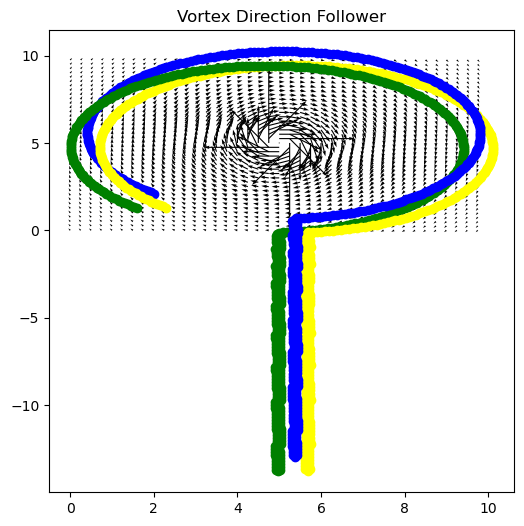

 Initial Positions [2, 2.1] [2.3, 1.3] [1.6, 1.28]
Vortex Direction Source


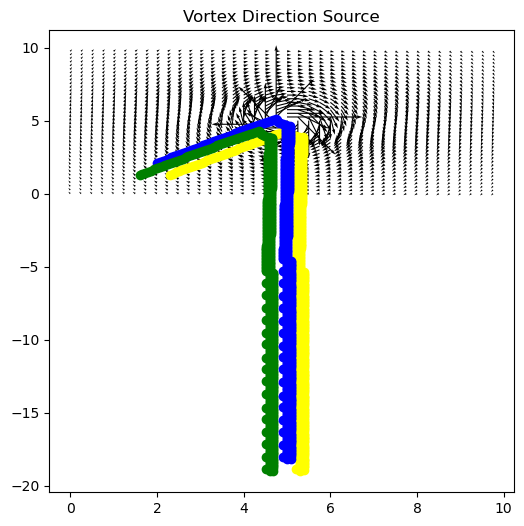

 Initial Positions [2, 2.1] [2.3, 1.3] [1.6, 1.28]
Vortex Magnitude Follower


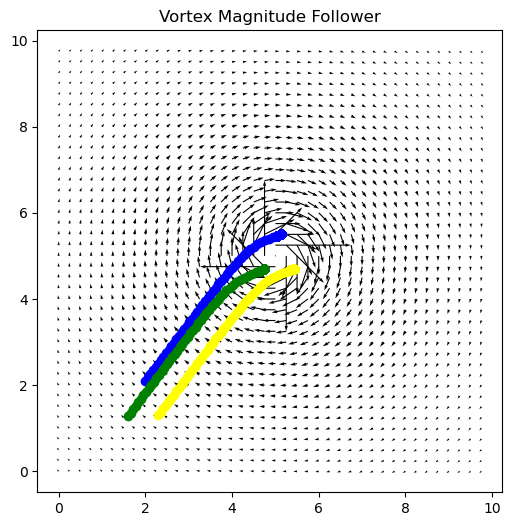

 Initial Positions [2, 2.1] [2.3, 1.3] [1.6, 1.28]
Magnitude Source


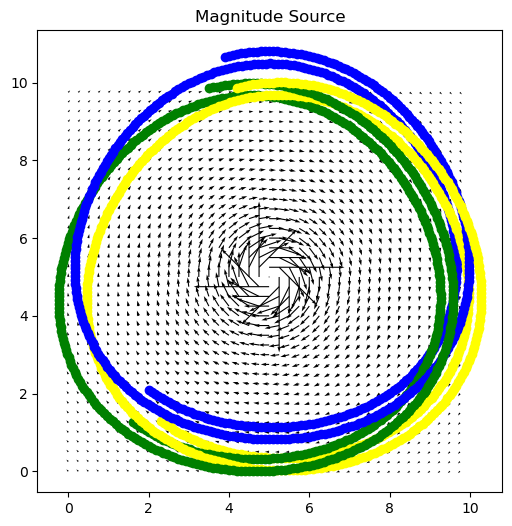

In [9]:
# 9. Execute the simulations
# I am not sure why I chose these 4 simulations, and not all of them.

# Vortex Direction Follower
reset_constants()
reset_cluster()
execute_simulation(vortex_direction_follower, 'Vortex Direction Follower')

# Vortex Direction Source
reset_constants()
reset_cluster()
execute_simulation(vortex_direction_source, 'Vortex Direction Source')

# Vortex Magnitude Follower
reset_constants()
reset_cluster()
execute_simulation(vortex_magnitude_follower, 'Vortex Magnitude Follower')

# Vortex Magnitude Source
reset_constants()
reset_cluster()
execute_simulation(vortex_magnitude_source, 'Magnitude Source')

Some thoughts:

These all work well in smooth fields. However, we do need to introduce both the concept of noise in the field, and in sensor noise. To compensate for the noise, we may need something in this form:

V(system) = V(system) + alpha*( f(environment) - V(system) ) 